![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_4/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller: Identificando  Burger Master con MMG

El Burger Master es un evento creado en el 2016 por el *influencer* Tulio Zuluaga, más conocido en redes como Tulio recomienda, el cual busca que por una semana las hamburgueserías de cada ciudad ofrezcan su mejor producto a un precio reducido.

El evento ha venido creciendo y en el 2022 se extendió por 21 ciudades de Colombia para las cuales se estimó que se vendieron más de dos millones de hamburguesas. El objetivo del presente caso-taller  es identificar los puntos calientes de hamburgueserías  que compitieron en  la ciudad de Bogotá aplicando el Modelo de Mezclas Gaussianas.

## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Alistar ambiente de trabajo

> Nota función here(): Para usar la función here() es necesario crear un archivo vació llamado .here que le indique a la función cuál es el directorio de trabajo. Recomiendo crear el archivo desde la terminal para no tener problemas con las extensiones

In [90]:
#Cargar paquetes necesarios ----------------------------------------------
from pyprojroot import here # Referenciación de archivos, es here() para python 
from pathlib import Path # Facilita rutas a los archivos 
import pandas as pd #Análisis de datos
import numpy as np #Cálculos numéricos
import os #Definir el directorio
import seaborn as sns #Visualización de datos
from matplotlib import pyplot as plt #Visualización de datos
import re #Expresiones regulares
import geopandas as gpd
from shapely.geometry import Point
import folium #Mapa interactivo 
import statsmodels.api as sm
from sklearn.mixture import GaussianMixture
from scipy.stats import norm, multivariate_normal
from sklearn.model_selection import GridSearchCV

In [91]:
#Definir el directorio de trabajo ----------------------------------------
wd = here()
os.chdir(wd)
os.listdir()

['mapa_kde_vs_gmm.html',
 '.DS_Store',
 '.here',
 'figs',
 'code',
 'data',
 'mapa_hamburguesas_bogota.html']

## Desarrollo

### 1. Carga de datos  

En la carpeta `data` se encuentra el archivo `burger_master.xlsx` para la ciudad de Bogotá, cargue estos datos en su *cuaderno* y reporte brevemente el contenido de la base.

In [92]:
#Cargar datos ---------------------------------------------------
burger_master_db = pd.read_excel("data/burger_master.xlsx")
burger_master_db.head()

,Restaurante,Dirección,Descripción,Latitud,Longitud
0,MAIKKI,Cra 75 # 24D – 48,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.668833,-74.116828
1,MAIKKI,Calle 119 # 11A – 24,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.698395,-74.036585
2,MAIKKI,Cra 47A # 98 – 47,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.686401,-74.060144
3,FRENCHEESE,Calle 51 #22-55,"<p>Presentamos «La French Master», inspirada e...",4.639514,-74.073545
4,FRENCHEESE,Calle 80 #14-41,"<p>Presentamos «La French Master», inspirada e...",4.666147,-74.056758


In [93]:
#Análsis preliminar de los datos ----------------------------------

#(1)Número de observaciones 
burger_master_db.shape

(137, 5)

In [94]:
#(2) Tipo de las variables y estadísticas descriptivas
burger_master_db.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Restaurante,137,63,LA HAMBURGUESERÍA,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dirección,137,116,Av. El Dorado # 68c – 61,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Descripción,137,63,<p>#EraGolDeYepes! Burger Master Edition: Una ...,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitud,137.0,NaN,NaN,NaN,4.677799,0.060859,4.577111,4.643376,4.667144,4.699399,4.892476
Longitud,137.0,NaN,NaN,NaN,-74.074729,0.031671,-74.160764,-74.094575,-74.064046,-74.053926,-74.029229


In [95]:
#(3) Ver missing values 
missings_db = burger_master_db.isna().sum()
print(missings_db)

Restaurante    0
Dirección      0
Descripción    0
Latitud        0
Longitud       0
dtype: int64


> Nota: posiblemente la base tiene duplicados, porque el número único de direcciones debería corresponder con el número de observaciones. Una cadena de restaurantes puede tener más de un local, pero cada local debería tener una sola dirección.

In [96]:
#(4) Contar duplicados 
duplicates_db = burger_master_db.duplicated().sum()
print(duplicates_db)

21


En efecto la base tiene 21 duplicados, que es la diferencia entre el número de observaciones y el número de direcciones. Los vamos a remover. 

In [97]:
#(5) Remover duplicados
burger_master_db = burger_master_db.drop_duplicates()
burger_master_db.shape

(116, 5)

**Contenido de la base**

La base tiene información sobre los restaurantes participantes en el Burger Master de Bogotá. Para cada restaurante tenemos:

* Nombre.
* Dirección escrita.
* Coordenadas de su ubicación.
* Descripción de la hamburguesa con la que decidieron participar.

Hay 63 restaurantes participantes, cada uno con su respectiva hamburguesa. Algunos restaurantes tienen más de un local, por lo que en total hay 116 establecimientos.

### 2.  Visualizando los datos

Visualice la ubicación de cada restaurante en un mapa interactivo. Añada un marcador para cada restaurante y la posibilidad de encontrar la descripción de la hamburguesa ofrecida en un pop-up. (Note que la columna Descripción contiene otra información adicional).

#### 2.1 Preparar los datos para hacer el mapa

En este caso, las descripciones de los locales participantes del Burger Master también tienen información sobre la dirección del local y sobre si el restaurante tiene más puntos además de los demás establecimientos. Para hacer el mapa, vamos a conservar únicamente la descripción de la hamburguesa.

In [98]:
#(1) Guardar solo la descripción de la hamburguesa. 

#(2.1)Hacer una función para extraer el texto de la descripción de la hamburguesa. 
def extraer_texto(html_text):
    if pd.isna(html_text):
        return None
    
    patron = r'<p>(.*?)(?:<br.*?>|</p>)'
    match = re.search(patron, str(html_text), re.DOTALL)
    
    return match.group(1).strip() if match else html_text

#(2.2)Conservar sola la descripción de la hamburguesa.
burger_master_db["hamburguesa_descripcion"] = burger_master_db["Descripción"].apply(extraer_texto)

#(2.3) Ver como quedaron las descripciones de las hamburguesas.
burger_master_db["hamburguesa_descripcion"].head(10)


0    MAIKKI MACUIRA: Cama de chicharrón soplado, to...
1    MAIKKI MACUIRA: Cama de chicharrón soplado, to...
2    MAIKKI MACUIRA: Cama de chicharrón soplado, to...
3    Presentamos «La French Master», inspirada en n...
4    Presentamos «La French Master», inspirada en n...
5    ¡Nuestra hamburguesa es un viaje por las regio...
6    HECHICERA: Es un embrujo, es magia, es PURO SA...
7    En familia logramos componer una hamburguesa l...
8    En familia logramos componer una hamburguesa l...
9    En familia logramos componer una hamburguesa l...
Name: hamburguesa_descripcion, dtype: object

#### 2.4 Hacer el mapa

In [99]:
# Crear mapa centrado en Bogotá
m = folium.Map(
    location=[4.7110, -74.0721],
    tiles="OpenStreetMap",
    zoom_start=12
)

# Agregar cada punto con su descripción
for _, r in burger_master_db.iterrows():
    # Extraer coordenadas del punto
    lat = r['Latitud']
    lon = r['Longitud']
    
    # Crear popup con la descripción
    popup_html = f"""
    <div style="width: 300px;">
        <h4>{r['Restaurante']}</h4>
        <p>{r['hamburguesa_descripcion']}</p>
    </div>
    """
    
    # Agregar marcador
    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(popup_html, max_width=350),
        tooltip=r['Restaurante'],  # Muestra el nombre al pasar el mouse
        icon=folium.Icon(color='red', icon='cutlery', prefix='fa')
    ).add_to(m)

# Mostrar mapa
m.save('mapa_hamburguesas_bogota.html')
m

### 3.  Análisis de puntos calientes

Aplique el modelo de Mezclas Gaussianas para buscar clusters de restaurantes en Bogotá, mencione qué estructura de covarianza usó y explique por qué. Escoja el número óptimo de componentes, explicando el procedimiento y justificando su elección.

#### 3.0 Escoger los hiperparámetros del modelo GMM

Para escoger los hiperparámetros del modelo, buscamos la combinación de *número de componentes* y *tipo de covarianza* que nos dé el `BIC` más bajo. Buscamos minimizar el BIC porque esta métrica balancea entre el ajuste y la complejidad del modelo. Esto nos permite encontrar los grupos sin fragmentar excesivamente los clústeres.

**Grilla de búsqueda**

* **Número de componentes:** Vamos a usar una grilla desde 1 hasta 8. Establecemos que el máximo de la grilla sea 8 porque, al explorar el mapa, podemos observar concentración de restaurantes en 6 ubicaciones (Usaquén, Chapinero, La Candelaria, Kennedy, Fontibón y la ciudad de Chía). Ponemos 8 para probar más casos de los que consideramos plausibles.

* **Covarianza utilizada:** Vamos a probar con los tres tipos de covarianza para ver cuál genera el mejor ajuste.


Mejor combinación:
  n_components    = 4
  covariance_type = full
  BIC             = -916.1121


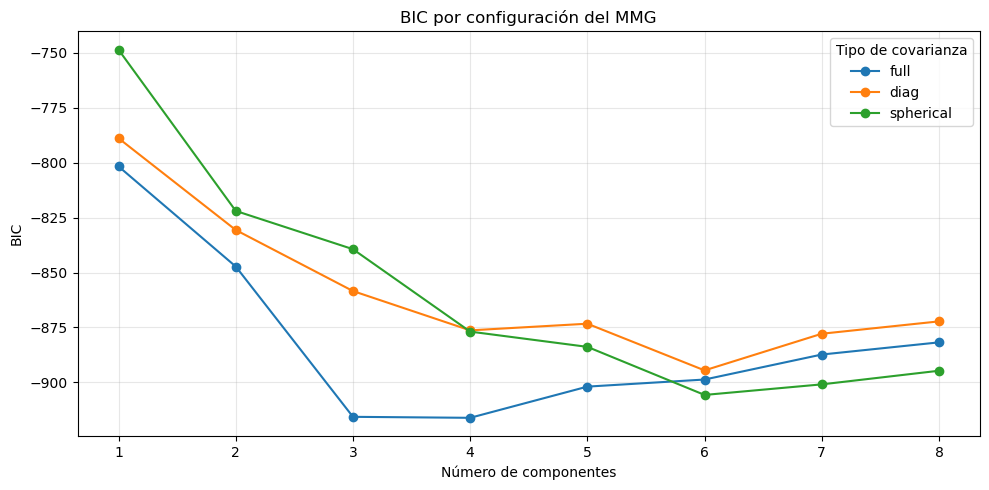

In [100]:
#Grilla de búsqueda de hiperparámetros ----------------------------

#(1) Preparamos los datos. El modelo usa la latitud y la longitud 
X = burger_master_db[['Latitud', 'Longitud']].values

#(2) Definimos la grilla de busqueda
n_components_range = range(1, 9)                             # 1 a 8 componentes
covariance_types   = ['full', 'diag', 'spherical']  # 3 tipos de covarianza

#(3) Corremos el modelo para cada una de las combinaciones de hiperparámetros
bic_results = []

for cov_type in covariance_types:
    for n_comp in n_components_range:
        gmm = GaussianMixture(n_components=n_comp,
                              covariance_type=cov_type,
                              random_state=1234,
                              n_init=5)       # múltiples inicializaciones para estabilidad
        gmm.fit(X)
        bic_results.append({
            'n_components'    : n_comp,
            'covariance_type' : cov_type,
            'BIC'             : gmm.bic(X)
        })

bic_df = pd.DataFrame(bic_results)

#(4) Encontramos el mejor modelo (vemos que combinación minimizo el BIC)
best_idx    = bic_df['BIC'].idxmin()
best_params = bic_df.loc[best_idx]
print(f"Mejor combinación:")
print(f"  n_components    = {int(best_params['n_components'])}")
print(f"  covariance_type = {best_params['covariance_type']}")
print(f"  BIC             = {best_params['BIC']:.4f}")

#(5) Vemos los resultados gráficamente
fig, ax = plt.subplots(figsize=(10, 5))
for cov_type in covariance_types:
    subset = bic_df[bic_df['covariance_type'] == cov_type]
    ax.plot(subset['n_components'], subset['BIC'], marker='o', label=cov_type)

ax.set_xlabel('Número de componentes')
ax.set_ylabel('BIC')
ax.set_title('BIC por configuración del MMG')
ax.legend(title='Tipo de covarianza')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### 3.2 Estimar el modelo

Usamos los hiperparámetros encontrados para estimar el modelo.

In [101]:
#(5) Corremos el mejor modelo
best_model = GaussianMixture(
    n_components    = int(best_params['n_components']),
    covariance_type = best_params['covariance_type'],
    random_state    = 1234,
    n_init          = 5
)
best_model.fit(X)
burger_master_db['cluster'] = best_model.predict(X)

**Modelo con el mejor ajuste**

El modelo con el mejor ajuste usa la covarianza *full* y 4 componentes. Consideramos que el modelo escogió la covarianza *full* porque los clústeres de restaurantes tienen formas irregulares que se pueden aproximar mejor usando este tipo de covarianza, que es la más flexible.

El número óptimo de componentes encontrado es 4. Es probable que el modelo haya preferido no atomizar excesivamente los grupos.

#### 3.3. Visualización de los resultados

Visualice las densidades estimadas por el  mejor modelo estimado en la sección anterior usando un mapa de calor interactivo, discuta los resultados.

In [113]:
#(1) Definir el canvas del mapa
m_clusters = folium.Map(location = [burger_master_db['Latitud'].mean(),burger_master_db['Longitud'].mean()], tiles = "OpenStreetMap", zoom_start = 12)


#(2) Establecer los colores de los clústers
colour = ['red',
    'orange',
    'green', 
    'blue']

def colorCall(val):
  val = int(val)
  return colour[val]

#(3) Agregar los clústers
for lat, lon, c in zip(burger_master_db['Latitud'], burger_master_db['Longitud'], burger_master_db['cluster']):
    folium.CircleMarker(
        [lat, lon],
        radius=8,
        fill_color = colorCall(c),
        fill=True,
        color=colorCall(c),
        fill_opacity=0.7
        ).add_to(m_clusters)
    
#(4) Hacemos un punto para centrar el mapa en la plaza de Bolívar
PB = pd.DataFrame({
    "lugar": ["Plaza de Bolívar"],
    "Latitud": [4.598128],
    "Longitud": [-74.076044]
    })

#(5) Agremos el centro en la plaza de Bolívar al mapa
folium.Marker(
      location=[PB.iloc[0]['Latitud'], PB.iloc[0]['Longitud']]
).add_to(m_clusters)

#(6) Visualizar el mapa
m_clusters

El algoritmo hizo 4 clústeres. Los clústeres correspondientes a las hamburgueserías en Usaquén y en Chía tienen restaurantes que están más cerca entre sí. Los otros dos clústeres generados están más dispersos y tienen restaurantes en varias localidades.

El algoritmo generó clústeres con formas flexibles. Parece que el algoritmo es muy bueno detectando concentraciones de restaurantes. Sin embargo, cuando hay *outliers*, parece que la distribución se expande para alcanzarlos, lo que podría explicar los clústeres alargados (azul y rojo) que observamos.

> Conclusión: el algoritmo logra encontrar muy bien los centros con varios restaurantes, pero es sensible a los *outliers* y la dispersión entre los puntos. 


### 4. Comparación con KDE

Estime ahora las densidades usando KDE bivariado de la librería `statsmodels` con el anchos de banda dado por `cv_ml`. Muestre los resultados usando un mapa interactivo. Compare los resultados obtenidos por el "mejor" modelo encontrado via MMG.

#### 4.1 Estimamos los puntos calientes usando KDE

In [104]:
# Preparamos los datos (los volvemos un objeto espacial) ---------------------------

#(1)Extraemos la longitud y la latitud de los datos
X_geo = burger_master_db[['Longitud', 'Latitud']].copy()
X_geo.columns = ['lon', 'lat']

In [105]:
#(2) Encontramos el ancho de banda usando CrossValidation
dens_u = sm.nonparametric.KDEMultivariate(data=X_geo, var_type='cc', bw='cv_ml')
dens_u.bw

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/nonparametric/kernel_density.py:158: RuntimeWarning: invalid value encountered in log
  L += func(f_i)


array([0.00511833, 0.0086919 ])

In [106]:
#(3) Definimos la grilla con las observaciones. 
x = np.linspace(min(X_geo.lon), max(X_geo.lon), 200)
y = np.linspace(min(X_geo.lat), max(X_geo.lat), 200)
xx, yy = np.meshgrid(x, y)
grid = np.column_stack(( xx.flatten(),yy.flatten()))
grid

array([[-74.1607644 ,   4.577111  ],
       [-74.16010342,   4.577111  ],
       [-74.15944244,   4.577111  ],
       ...,
       [-74.03055096,   4.892476  ],
       [-74.02988998,   4.892476  ],
       [-74.029229  ,   4.892476  ]])

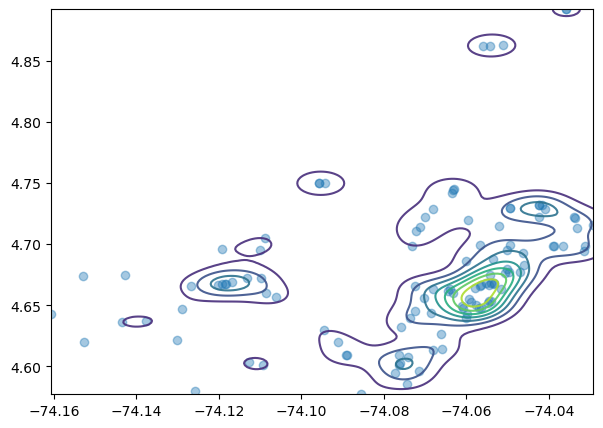

In [107]:
#(5) Estimamos las densidades para las observaciones
densidad_pred=dens_u.pdf(data_predict=grid)

#(6) Visualizemos los puntos encontrados 
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 5))


ax.scatter(X_geo.lon, X_geo.lat, alpha=0.4)
ax.contour(
    xx, yy, densidad_pred.reshape(xx.shape),
    alpha =0.9
)

#### 4.2 Hacemos el mapa para comparar los resultados de los dos algoritmos

In [ ]:
from folium.plugins import HeatMap

# (6) Reescalar la densidad para poder hacer el mapa (200 x 200)
densidad_grid = densidad_pred.reshape(xx.shape)

# (7) Construir lista [lat, lon, peso] para el mapa de calor
#     yy → latitudes, xx → longitudes (tal como los definimos en el meshgrid)
heat_data = [
    [yy[i, j], xx[i, j], float(densidad_grid[i, j])]
    for i in range(yy.shape[0])
    for j in range(xx.shape[1])
    if densidad_grid[i, j] > 0
]

# (8) Normalizar pesos al rango [0, 1]
max_w = max(h[2] for h in heat_data)
heat_data_norm = [[h[0], h[1], h[2] / max_w] for h in heat_data]

# (9) Agregar capa KDE al mapa de clústeres del MMG
HeatMap(
    heat_data_norm,
    name        = "Densidad KDE (cv_ml)",
    radius      = 25,
    blur        = 20,
    min_opacity = 0.2,
    max_zoom    = 18
).add_to(m_clusters)

# (10) Agregar control de capas para activar/desactivar el KDE
folium.LayerControl(collapsed=False).add_to(m_clusters)

# (11) Guardar y mostrar
m_clusters

**Conclusiones**

*GMM* encontró 4 puntos calientes de restaurantes. Estos puntos tienen fronteras suaves y encuentran correctamente los grupos más densos (identificaron correctamente las mayores concentraciones de restaurantes). Cuando aplicamos *KDE*, pudimos observar que este algoritmo reveló otros puntos calientes menos densos (concentraciones con menos restaurantes). Si queremos explorar la densidad y el poder computacional lo permite, es mejor usar *KDE* para encontrar los puntos calientes.

> Nota: *GMM* tiene la ventaja de que nos permite asignar las observaciones a clústeres, mientras que *KDE* nos muestra la densidad de los puntos. Si queremos hacer clústeres, ambos algoritmos se complementan: *GMM* encuentra los clústeres y *KDE* nos ayuda a identificar si podría ser buena idea segmentar más.